In [ ]:
import pandas as pd

In [ ]:
# Unidad funcional
unit = "1 cotton t-shirt (0.18 kg) delivered to Milan"

# Datos del sistema
data = {
    "process": [
        "Cotton production",
        "Electricity for manufacturing",
        "Sea transport Peru to Italy",
        "Truck transport in Italy"
    ],
    "quantity": [
        0.18,     # kg cotton
        0.5,      # kWh electricity
        10500 * 0.00018,  # tonne-km (distance * weight in tonnes)
        300 * 0.00018     # tonne-km
    ],
    "emission_factor": [
        5.5,      # kgCO2e per kg cotton (example value)
        0.233,    # kgCO2e per kWh (example electricity)
        0.015,    # kgCO2e per tonne-km sea freight
        0.1       # kgCO2e per tonne-km truck
    ]
}

df = pd.DataFrame(data)
df

,process,quantity,emission_factor
0,Cotton production,0.180,5.500
1,Electricity for manufacturing,0.500,0.233
2,Sea transport Peru to Italy,1.890,0.015
3,Truck transport in Italy,0.054,0.100


In [ ]:
df["emissions_kgCO2e"] = df["quantity"] * df["emission_factor"]

total_emissions = df["emissions_kgCO2e"].sum()

df

,process,quantity,emission_factor,emissions_kgCO2e
0,Cotton production,0.180,5.500,0.99000
1,Electricity for manufacturing,0.500,0.233,0.11650
2,Sea transport Peru to Italy,1.890,0.015,0.02835
3,Truck transport in Italy,0.054,0.100,0.00540


In [ ]:
print("--------------------------------------------------")
print("Mini LCA Result")
print("--------------------------------------------------")
print(f"Unit functional: {unit}")
print("--------------------------------------------------")

for index, row in df.iterrows():
    print(f"{row['process']}: {round(row['emissions_kgCO2e'], 3)} kgCO2e")

print("--------------------------------------------------")
print(f"TOTAL FOOTPRINT: {round(total_emissions, 3)} kgCO2e per t-shirt")
print("--------------------------------------------------")

--------------------------------------------------
Mini LCA Result
--------------------------------------------------
Unit functional: 1 cotton t-shirt (0.18 kg) delivered to Milan
--------------------------------------------------
Cotton production: 0.99 kgCO2e
Electricity for manufacturing: 0.117 kgCO2e
Sea transport Peru to Italy: 0.028 kgCO2e
Truck transport in Italy: 0.005 kgCO2e
--------------------------------------------------
TOTAL FOOTPRINT: 1.14 kgCO2e per t-shirt
--------------------------------------------------


In [ ]:
data = [
    ["Cotton production", 0.18, 5.5],
    ["Electricity manufacturing", 0.5, 0.233],
    ["Sea transport Peru-Italy", 10500 * 0.00018, 0.015],
    ["Truck transport Italy", 300 * 0.00018, 0.1]
]

df = pd.DataFrame(data, columns=["process", "quantity", "emission_factor"])
df.to_csv("mini_lca_textil.csv", index=False)

print("CSV created successfully.")

CSV created successfully.


In [ ]:
df = pd.read_csv("mini_lca_textil.csv")

df["emissions_kgCO2e"] = df["quantity"] * df["emission_factor"]

total_emissions = df["emissions_kgCO2e"].sum()

df

,process,quantity,emission_factor,emissions_kgCO2e
0,Cotton production,0.180,5.500,0.99000
1,Electricity manufacturing,0.500,0.233,0.11650
2,Sea transport Peru-Italy,1.890,0.015,0.02835
3,Truck transport Italy,0.054,0.100,0.00540


In [ ]:
data = [
    ["Cotton production", "Material", 0.18, 5.5],
    ["Electricity manufacturing", "Production", 0.5, 0.233],
    ["Sea transport Peru-Italy", "Transport", 10500 * 0.00018, 0.015],
    ["Truck transport Italy", "Transport", 300 * 0.00018, 0.1]
]

df = pd.DataFrame(data, columns=["process", "category", "quantity", "emission_factor"])
df.to_csv("mini_lca_textil.csv", index=False)

print("CSV updated correctly.")

CSV updated correctly.


In [ ]:
df = pd.read_csv("mini_lca_textil.csv")

df["emissions_kgCO2e"] = df["quantity"] * df["emission_factor"]

df

,process,category,quantity,emission_factor,emissions_kgCO2e
0,Cotton production,Material,0.180,5.500,0.99000
1,Electricity manufacturing,Production,0.500,0.233,0.11650
2,Sea transport Peru-Italy,Transport,1.890,0.015,0.02835
3,Truck transport Italy,Transport,0.054,0.100,0.00540


In [ ]:
category_summary = df.groupby("category")["emissions_kgCO2e"].sum()

total_emissions = df["emissions_kgCO2e"].sum()

print("Category Breakdown:")
print(category_summary)

print("\nTOTAL:", round(total_emissions, 3), "kgCO2e per t-shirt")

Category Breakdown:
category
Material      0.99000
Production    0.11650
Transport     0.03375
Name: emissions_kgCO2e, dtype: float64

TOTAL: 1.14 kgCO2e per t-shirt


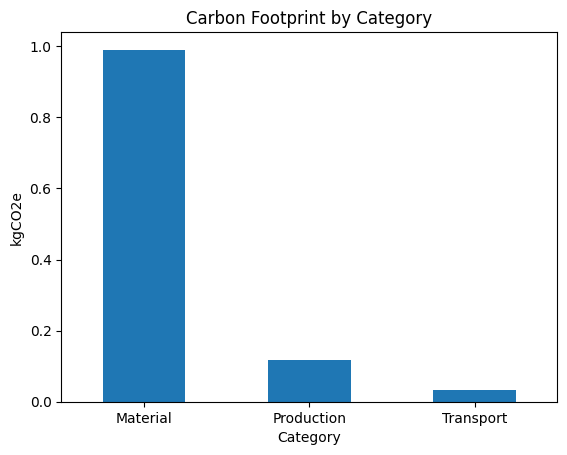

In [ ]:
import matplotlib.pyplot as plt

# Gráfico de barras
category_summary.plot(kind='bar')

plt.title("Carbon Footprint by Category")
plt.ylabel("kgCO2e")
plt.xlabel("Category")
plt.xticks(rotation=0)

plt.show()

In [ ]:
percentage = (category_summary / total_emissions) * 100

print("Percentage contribution by category:")
print(round(percentage, 2))

Percentage contribution by category:
category
Material      86.82
Production    10.22
Transport      2.96
Name: emissions_kgCO2e, dtype: float64


In [ ]:
# Imports y utilidades
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from google.colab import files

plt.rcParams.update({'figure.max_open_warning': 0})


In [ ]:
# Subir CSV (botón) o usar la plantilla embebida si prefieres
print("Sube tu CSV (mini_lca_textil.csv preferible) o espera 10s para cargar plantilla de ejemplo automática.")

uploaded = files.upload()  # ventana para subir archivo
if uploaded:
    # toma el primer archivo subido
    fname = list(uploaded.keys())[0]
    df = pd.read_csv(io.BytesIO(uploaded[fname]))
    print(f"Archivo cargado: {fname}")
else:
    # Plantilla de ejemplo (si no subes nada)
    data = [
        ["Cotton production", "Material", "kg", 0.18, 5.5, "kgCO2e/kg", np.nan, np.nan, "raw cotton weight"],
        ["Electricity manufacturing", "Production", "kWh", 0.5, 0.233, "kgCO2e/kWh", np.nan, np.nan, "estimated kWh per shirt"],
        ["Sea transport Peru-Italy", "Transport", "tonne_km", np.nan, 0.015, "kgCO2e/tonne_km", 180, 10500, "use weight_km -> tonne_km computed"],
        ["Truck transport Italy", "Transport", "tonne_km", np.nan, 0.1, "kgCO2e/tonne_km", 180, 300, ""]
    ]
    df = pd.DataFrame(data, columns=["process","category","unit","quantity","emission_factor","factor_unit","weight_kg","distance_km","notes"])
    print("Plantilla de ejemplo cargada (puedes subir tu CSV ahora para reemplazarla).")

display(df.head(20))


Sube tu CSV (mini_lca_textil.csv preferible) o espera 10s para cargar plantilla de ejemplo automática.


Saving mini_lca_textil_template_fixed.csv to mini_lca_textil_template_fixed.csv
Archivo cargado: mini_lca_textil_template_fixed.csv


,process,category,unit,quantity,emission_factor,factor_unit,weight_kg,distance_km,notes
0,Cotton production,Material,kg,0.18,5.500,kgCO2e/kg,NaN,NaN,raw cotton weight
1,Electricity manufacturing,Production,kWh,0.50,0.233,kgCO2e/kWh,NaN,NaN,estimated kWh per shirt
2,Sea transport Peru-Italy,Transport,tonne_km,NaN,0.015,kgCO2e/tonne_km,180.0,10500.0,"if you provide weight_kg+distance_km, quantity..."
3,Truck transport Italy,Transport,tonne_km,NaN,0.100,kgCO2e/tonne_km,180.0,300.0,NaN


In [ ]:
# Validaciones básicas y cálculo quantity si weight_kg + distance_km están presentes para transport
df = df.copy()

# Normaliza columnas faltantes
for col in ["process","category","unit","quantity","emission_factor","factor_unit","weight_kg","distance_km","notes"]:
    if col not in df.columns:
        df[col] = np.nan

# Si unit indica 'tonne_km' o es transporte y quantity es NaN pero weight_kg & distance_km tienen valores -> compute
def compute_quantity(row):
    unit = str(row['unit']).strip().lower() if pd.notna(row['unit']) else ""
    if (unit == "tonne_km" or str(row['category']).strip().lower() == "transport"):
        if pd.isna(row['quantity']):
            if pd.notna(row.get('weight_kg')) and pd.notna(row.get('distance_km')):
                try:
                    tonne_km = (float(row['weight_kg'])/1000.0) * float(row['distance_km'])
                    return tonne_km
                except:
                    return np.nan
    # fallback: return existing quantity
    return row['quantity']

df['quantity_computed'] = df.apply(compute_quantity, axis=1)

# If still NaN for quantity, try converting numeric strings
df['quantity_computed'] = df['quantity_computed'].apply(lambda x: np.nan if pd.isna(x) else float(x))

# Validate emission_factor numeric
def safe_float(x):
    try:
        return float(x)
    except:
        return np.nan

df['emission_factor'] = df['emission_factor'].apply(safe_float)

# Report warnings if missing data
missing_qty = df[df['quantity_computed'].isna()]
missing_factors = df[df['emission_factor'].isna()]

if not missing_qty.empty:
    print("ATENCIÓN: Las siguientes filas no tienen quantity calculable (falta quantity o weight_kg/distance_km):")
    display(missing_qty[['process','category','unit','quantity','weight_kg','distance_km','notes']])

if not missing_factors.empty:
    print("ATENCIÓN: Las siguientes filas no tienen emission_factor numérico:")
    display(missing_factors[['process','category','emission_factor','factor_unit','notes']])

# Show cleaned preview
display(df[['process','category','unit','quantity_computed','emission_factor','factor_unit']])

,process,category,unit,quantity_computed,emission_factor,factor_unit
0,Cotton production,Material,kg,0.18,5.500,kgCO2e/kg
1,Electricity manufacturing,Production,kWh,0.50,0.233,kgCO2e/kWh
2,Sea transport Peru-Italy,Transport,tonne_km,1890.00,0.015,kgCO2e/tonne_km
3,Truck transport Italy,Transport,tonne_km,54.00,0.100,kgCO2e/tonne_km


In [ ]:
# Calcula emisiones por fila y tabulado
df['emissions_kgCO2e'] = df['quantity_computed'] * df['emission_factor']

# Si hay NaN ahora, marca y detalla
errors = df[df['emissions_kgCO2e'].isna()]
if not errors.empty:
    print("ERROR: Algunas filas no pudieron calcular emisiones. Revisa quantity o emission_factor.")
    display(errors[['process','quantity_computed','emission_factor','notes']])

# Resultados por proceso
display(df[['process','category','unit','quantity_computed','emission_factor','emissions_kgCO2e']].round(6))
total_emissions = df['emissions_kgCO2e'].sum(skipna=True)
print("\nTOTAL FOOTPRINT (sum):", round(total_emissions,6), "kgCO2e per unit functional")

,process,category,unit,quantity_computed,emission_factor,emissions_kgCO2e
0,Cotton production,Material,kg,0.18,5.500,0.9900
1,Electricity manufacturing,Production,kWh,0.50,0.233,0.1165
2,Sea transport Peru-Italy,Transport,tonne_km,1890.00,0.015,28.3500
3,Truck transport Italy,Transport,tonne_km,54.00,0.100,5.4000



TOTAL FOOTPRINT (sum): 34.8565 kgCO2e per unit functional


In [ ]:
# Agrupar por categoria
category_summary = df.groupby('category', dropna=False)['emissions_kgCO2e'].sum().sort_values(ascending=False)
percentage = (category_summary / total_emissions) * 100

summary_df = pd.DataFrame({
    'emissions_kgCO2e': category_summary,
    'percentage_%': percentage.round(2)
})

display(summary_df.round(6))

# Añadir filas de totales al detalle y exportar resultados
df_out = df.copy()
df_out['total_footprint_kgCO2e'] = total_emissions
df_out.to_csv("mini_lca_results.csv", index=False)
print("Resultados exportados a mini_lca_results.csv — descárgalo con el botón a continuación.")
files.download("mini_lca_results.csv")

,emissions_kgCO2e,percentage_%
category,,
Transport,33.7500,96.83
Material,0.9900,2.84
Production,0.1165,0.33


Resultados exportados a mini_lca_results.csv — descárgalo con el botón a continuación.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

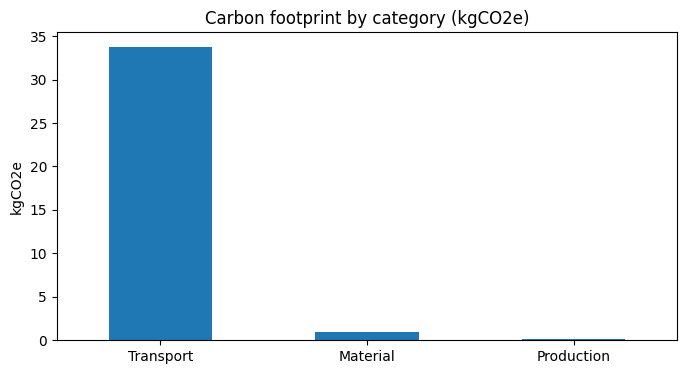

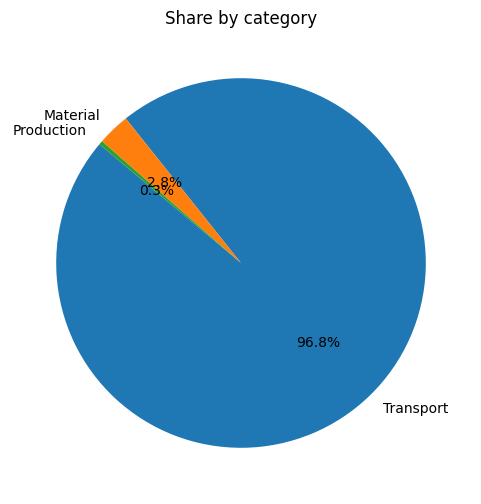

In [ ]:
# Barra
ax = category_summary.plot(kind='bar', figsize=(8,4))
ax.set_title("Carbon footprint by category (kgCO2e)")
ax.set_ylabel("kgCO2e")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.show()

# Pie (porcentaje)
plt.figure(figsize=(6,6))
plt.pie(category_summary, labels=category_summary.index, autopct='%1.1f%%', startangle=140)
plt.title("Share by category")
plt.show()

In [ ]:
# Función que permite aplicar un override a factores (útil para probar DEFRA vs estimado)
def recalc_with_overrides(overrides: dict):
    """
    overrides: dict {process_name: new_emission_factor}
    """
    df2 = df.copy()
    for p, newf in overrides.items():
        df2.loc[df2['process']==p, 'emission_factor'] = float(newf)
    df2['emissions_kgCO2e'] = df2['quantity_computed'] * df2['emission_factor']
    total = df2['emissions_kgCO2e'].sum()
    cat = df2.groupby('category')['emissions_kgCO2e'].sum()
    display(df2[['process','category','quantity_computed','emission_factor','emissions_kgCO2e']])
    print("TOTAL:", round(total,6))
    return df2, total, cat

# Ejemplo de uso:
# df2, tot2, cat2 = recalc_with_overrides({"Cotton production":4.8})

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving mini_lca_textil_with_defra.csv to mini_lca_textil_with_defra.csv


In [ ]:
import pandas as pd
df = pd.read_csv("mini_lca_textil_with_defra.csv")
df.head()


,process,category,unit,quantity,emission_factor,factor_unit,weight_kg,distance_km,notes,quantity_computed,emissions_kgCO2e
0,Cotton production,Material,kg,0.18,5.500,kgCO2e/kg,NaN,NaN,raw cotton weight,0.18,0.9900
1,Electricity manufacturing,Production,kWh,0.50,0.177,kgCO2e/kWh,NaN,NaN,estimated kWh per shirt,0.50,0.0885
2,Sea transport Peru-Italy,Transport,tonne_km,NaN,0.010,kgCO2e/tonne_km,180.0,10500.0,"if you provide weight_kg+distance_km, quantity...",1890.00,18.9000
3,Truck transport Italy,Transport,tonne_km,NaN,0.120,kgCO2e/tonne_km,180.0,300.0,NaN,54.00,6.4800


,Scenario,Total_kgCO2e,% vs Baseline
0,Baseline (Sea + Conventional Cotton),26.46,0.00
1,Air Freight,2275.56,8500.48
2,Recycled Cotton,25.83,-2.38


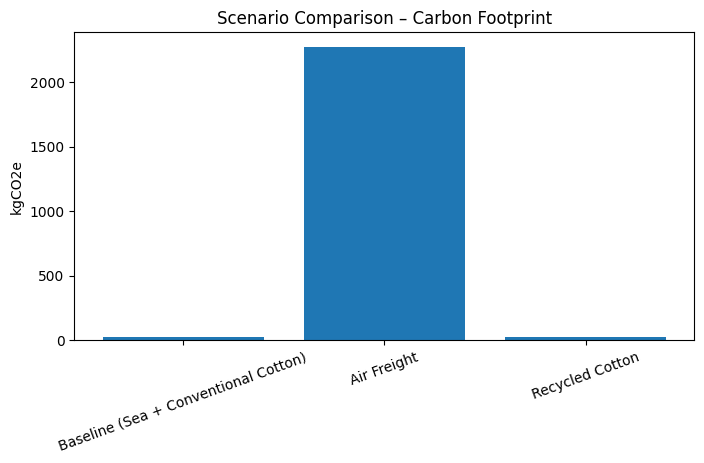

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurarnos que existe emissions_kgCO2e
if "emissions_kgCO2e" not in df.columns:
    df["emissions_kgCO2e"] = df["quantity_computed"] * df["emission_factor"]

def calculate_total(dataframe):
    return dataframe["emissions_kgCO2e"].sum()

# -------- BASELINE --------
baseline = df.copy()
total_baseline = calculate_total(baseline)

# -------- ESCENARIO 1: AIR FREIGHT --------
air = df.copy()
AIR_FACTOR = 1.2  # kgCO2e per tonne-km (aprox DEFRA air cargo)

air.loc[air["process"]=="Sea transport Peru-Italy","emission_factor"] = AIR_FACTOR
air["emissions_kgCO2e"] = air["quantity_computed"] * air["emission_factor"]
total_air = calculate_total(air)

# -------- ESCENARIO 2: RECYCLED COTTON --------
recycled = df.copy()
RECYCLED_COTTON_FACTOR = 2.0  # estimación conservadora

recycled.loc[recycled["process"]=="Cotton production","emission_factor"] = RECYCLED_COTTON_FACTOR
recycled["emissions_kgCO2e"] = recycled["quantity_computed"] * recycled["emission_factor"]
total_recycled = calculate_total(recycled)

# -------- TABLA COMPARATIVA --------
comparison = pd.DataFrame({
    "Scenario": [
        "Baseline (Sea + Conventional Cotton)",
        "Air Freight",
        "Recycled Cotton"
    ],
    "Total_kgCO2e": [
        total_baseline,
        total_air,
        total_recycled
    ]
})

comparison["% vs Baseline"] = ((comparison["Total_kgCO2e"] - total_baseline) / total_baseline) * 100

display(comparison.round(2))

# -------- GRÁFICO --------
plt.figure(figsize=(8,4))
plt.bar(comparison["Scenario"], comparison["Total_kgCO2e"])
plt.ylabel("kgCO2e")
plt.title("Scenario Comparison – Carbon Footprint")
plt.xticks(rotation=20)
plt.show()